In [1]:
import os, re, io, pickle, math, tempfile
from typing import Optional, List, Tuple, Dict
import numpy as np
import pandas as pd

# ---------------- Config ----------------
MODEL_PKL   = "LightGBM_classifier_200khz.pkl"

  
TEST_PATHS = [
    "Aug9_200khz_5_100m.csv",
    "Aug9_2_200khz_5_100m.csv",
    "Aug11_200khz_5_100m.csv",
    "Aug11_2_200khz_5_100m.csv",
    "Aug15_200khz_5_100m.csv",
    "Aug26_200khz_5_100m.csv",
    "Aug29_200khz_5_100m.csv",
]


DELIM       = ","
ENCODING    = "utf-8"
BLOCK_COLS  = 50_000
FLOAT_DT    = np.float32

PROB_THRESH   = 0.70
MARGIN_THRESH = 0.05

OUT_DIR = "Beaufort_outputs_200khz"
os.makedirs(OUT_DIR, exist_ok=True)

# Optional: suppress sklearn "feature names" warnings spam
import warnings
warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names.*",
    category=UserWarning
)

# ---------------- Helpers ----------------
def _safe_float_freq_label(x: object) -> Optional[float]:
    if x is None:
        return None
    s = str(x).strip().replace(",", ".")
    s = re.sub(r"[^0-9.\-]", "", s)
    if s in {"", ".", "-", "-.", ".-"}:
        return None
    try:
        return float(s)
    except Exception:
        return None

def _nice_freq_name(f) -> str:
    try:
        fv = float(f)
        return str(int(fv)) if float(int(fv)) == fv else str(fv)
    except Exception:
        return str(f)

def apply_open_set_rejection(proba, prob_thresh=0.70, margin_thresh=0.05):
    proba = np.asarray(proba, dtype=float)
    top_idx = np.argmax(proba, axis=1)
    sorted_proba = np.sort(proba, axis=1)[:, ::-1]
    max_p  = sorted_proba[:, 0]
    second = sorted_proba[:, 1] if proba.shape[1] > 1 else np.zeros(len(proba))
    rejected = (max_p < prob_thresh) | ((max_p - second) < margin_thresh)
    return top_idx, rejected

def _read_ncols_fast(csv_path: str, delim: str, encoding: str) -> int:
    # FAST: only reads header line (does NOT scan whole file)
    with open(csv_path, "r", encoding=encoding, newline="") as f:
        header_line = f.readline()
    return header_line.count(delim) + 1

def _build_freq_index_fast(csv_path: str, delim: str, encoding: str) -> Tuple[List[int], List[float]]:
    keep_rows, freqs = [], []
    with open(csv_path, "r", encoding=encoding, newline="") as f:
        _ = f.readline()  # header
        r = 0
        for line in f:
            if not line.strip():
                r += 1
                continue
            first = line.split(delim, 1)[0]
            fval = _safe_float_freq_label(first)
            if fval is not None:
                keep_rows.append(r)
                freqs.append(fval)
            r += 1
    return keep_rows, freqs

def _sanitize_payload(rest: str, delim: str) -> str:
    s = rest.strip().replace("\r", "").replace('"', "").replace("'", "")
    for tok in ("N/A", "NA", "NULL", "null"):
        s = s.replace(tok, "nan")
    if s.startswith(delim):
        s = "0" + s
    if s.endswith(delim):
        s = s + "0"
    # ",," -> ",0," (also handles ",,,")
    pat = re.escape(delim) + r"(?=" + re.escape(delim) + r")"
    s = re.sub(pat, f"{delim}0", s)
    return s

def _parse_numeric_row(rest: str, delim: str, dtype, n_c: int) -> np.ndarray:
    s = _sanitize_payload(rest, delim)
    try:
        arr = np.fromstring(s, sep=delim, dtype=dtype)
    except ValueError:
        arr = np.genfromtxt(
            io.StringIO(s),
            delimiter=delim,
            dtype=dtype,
            filling_values=0.0,
            invalid_raise=False
        )
    arr = np.atleast_1d(arr).astype(dtype, copy=False)
    if arr.size < n_c:
        tmp = np.zeros(n_c, dtype=dtype)
        tmp[:arr.size] = arr
        arr = tmp
    elif arr.size > n_c:
        arr = arr[:n_c]
    return arr

def _memmap_fill_fast(csv_path: str, delim: str, encoding: str,
                      keep_rows: List[int], n_cols: int, dtype=np.float32) -> Tuple[str, int]:
    # n_cols includes the first frequency column
    n_r = len(keep_rows)
    n_c = n_cols - 1  # ping columns

    mm_path = tempfile.mktemp(prefix="ultrawide_", suffix=".dat")
    mm = np.memmap(mm_path, mode="w+", dtype=dtype, shape=(n_r, n_c))

    target_row_pos = {r: i for i, r in enumerate(keep_rows)}

    with open(csv_path, "r", encoding=encoding, newline="") as f:
        _ = f.readline()  # header
        r = 0
        for line in f:
            pos = target_row_pos.get(r, None)
            if pos is not None:
                parts = line.rstrip("\n").split(delim, 1)
                rest = parts[1] if len(parts) > 1 else ""
                if delim != ",":
                    rest = rest.replace(",", ".")
                mm[pos, :] = _parse_numeric_row(rest, delim, dtype, n_c)
            r += 1

    mm.flush()
    del mm
    return mm_path, n_c

def _align_row_order(freqs: List[float], wanted: List[str]) -> List[int]:
    # Map available freqs -> row index in memmap
    avail: Dict[str, int] = {}
    for i, f in enumerate(freqs):
        key = _nice_freq_name(f)
        if key not in avail:
            avail[key] = i
    return [avail.get(_nice_freq_name(name), -1) for name in wanted]

def _write_counts_csv(out_path: str, counts: pd.Series):
    # counts is indexed by class name
    df = counts.rename("Count").to_frame()
    df.to_csv(out_path, index=True)

# ---------------- Main ----------------
with open(MODEL_PKL, "rb") as f:
    bundle = pickle.load(f)

model = bundle["model"]
le    = bundle["label_encoder"]
train_freq_cols = list(bundle["feature_columns"])
meta  = bundle.get("meta", {})

classes = np.asarray(getattr(le, "classes_", []), dtype=object)

# expected frequency window (best effort)
train_freq_vals = [ _safe_float_freq_label(x) for x in train_freq_cols ]
train_freq_vals = [ x for x in train_freq_vals if x is not None ]
if train_freq_vals:
    fmin, fmax = float(min(train_freq_vals)), float(max(train_freq_vals))
else:
    fmin, fmax = float("nan"), float("nan")

print(f"Loaded model: {meta.get('model_name', 'Model')}")
print(f"Classes: {list(classes)}")
print(f"#Features expected: {len(train_freq_cols)}")
print(f"Expected frequency window: [{fmin}, {fmax}] kHz")

for TEST_CSV in TEST_PATHS:
    if not os.path.exists(TEST_CSV):
        print(f"\n⚠️ Missing {TEST_CSV} — skipping.")
        continue

    mm_path = None
    mm = None
    try:
        # Only read header for ncols (do NOT scan file)
        n_cols_total = _read_ncols_fast(TEST_CSV, DELIM, ENCODING)

        # detect frequency rows (usually ~121 rows)
        keep_rows, freqs = _build_freq_index_fast(TEST_CSV, DELIM, ENCODING)
        if not keep_rows:
            raise RuntimeError(f"No frequency rows detected in {TEST_CSV} (first column not numeric-like).")

        # fill memmap with numeric data (shape ~ [n_freq_rows, n_pings])
        mm_path, n_ping = _memmap_fill_fast(TEST_CSV, DELIM, ENCODING, keep_rows, n_cols_total, dtype=FLOAT_DT)

        # align to training frequency columns
        picks = _align_row_order(freqs, train_freq_cols)
        overlap = sum(1 for p in picks if p >= 0)
        base = os.path.basename(TEST_CSV)
        print(f"\n[{base}] feature overlap: {overlap}/{len(train_freq_cols)} ({(overlap/len(train_freq_cols))*100:.1f}%)")

        mm = np.memmap(mm_path, mode="r", dtype=FLOAT_DT, shape=(len(keep_rows), n_ping))

        # streamed scoring -> counts only
        n_features = len(picks)
        n_blocks = math.ceil(n_ping / BLOCK_COLS)

        cls_counts: Dict[str, int] = {}
        for b in range(n_blocks):
            c0 = b * BLOCK_COLS
            c1 = min((b + 1) * BLOCK_COLS, n_ping)
            block_w = c1 - c0

            X_block = np.empty((block_w, n_features), dtype=FLOAT_DT)
            for j, p in enumerate(picks):
                X_block[:, j] = mm[p, c0:c1] if p >= 0 else 0.0

            proba = model.predict_proba(X_block)
            top_idx, rejected = apply_open_set_rejection(
                proba, prob_thresh=PROB_THRESH, margin_thresh=MARGIN_THRESH
            )

            pred = classes[top_idx].astype(str)
            if np.any(rejected):
                pred = pred.copy()
                pred[rejected] = "Unknown"

            uniq, cnts = np.unique(pred, return_counts=True)
            for u, c in zip(uniq, cnts):
                cls_counts[str(u)] = cls_counts.get(str(u), 0) + int(c)

        counts = pd.Series(cls_counts, name="count").sort_index()
        counts.index.name = "Predicted"

        stem = os.path.splitext(os.path.basename(TEST_CSV))[0]
        out_counts = os.path.join(OUT_DIR, f"{stem}_class_counts.csv")
        _write_counts_csv(out_counts, counts)

        print(f"✅ Saved class counts: {out_counts}")
        print("Class counts:")
        print(counts)

    finally:
        try:
            if mm is not None:
                del mm
        except Exception:
            pass
        if mm_path and os.path.exists(mm_path):
            try:
                os.remove(mm_path)
            except Exception:
                pass


Loaded model: Model
Classes: ['Atlantic Cod', 'Krill', 'Polar Cod', 'Shrimp', 'Zooplankton']
#Features expected: 121
Expected frequency window: [189.0, 249.0] kHz

[Aug9_200khz_5_100m.csv] feature overlap: 121/121 (100.0%)
✅ Saved class counts: Beaufort_outputs_200khz/Aug9_200khz_5_100m_class_counts.csv
Class counts:
Predicted
Atlantic Cod     1641
Krill           24345
Polar Cod       68368
Shrimp          29496
Unknown         47008
Zooplankton      7659
Name: count, dtype: int64

[Aug9_2_200khz_5_100m.csv] feature overlap: 121/121 (100.0%)
✅ Saved class counts: Beaufort_outputs_200khz/Aug9_2_200khz_5_100m_class_counts.csv
Class counts:
Predicted
Atlantic Cod      402
Krill            5694
Polar Cod       10347
Shrimp           5028
Unknown          8598
Zooplankton      1908
Name: count, dtype: int64

[Aug11_200khz_5_100m.csv] feature overlap: 121/121 (100.0%)
✅ Saved class counts: Beaufort_outputs_200khz/Aug11_200khz_5_100m_class_counts.csv
Class counts:
Predicted
Atlantic Cod     

In [2]:
import os, re, io, pickle, math, tempfile
from typing import Optional, List, Tuple, Dict
import numpy as np
import pandas as pd

# ---------------- Config ----------------
MODEL_PKL   = "LightGBM_classifier_120khz.pkl"


TEST_PATHS = [
    "Aug9_120khz_5_100m.csv",
    "Aug9_2_120khz_5_100m.csv",
    "Aug11_120khz_5_100m.csv",
    "Aug11_2_120khz_5_100m.csv",
    "Aug15_120khz_5_100m.csv",
    "Aug26_120khz_5_100m.csv",
    "Aug29_120khz_5_100m.csv",
]



DELIM       = ","
ENCODING    = "utf-8"
BLOCK_COLS  = 50_000
FLOAT_DT    = np.float32

PROB_THRESH   = 0.70
MARGIN_THRESH = 0.05

OUT_DIR = "Beaufort_outputs_120khz"
os.makedirs(OUT_DIR, exist_ok=True)

# Optional: suppress sklearn "feature names" warnings spam
import warnings
warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names.*",
    category=UserWarning
)

# ---------------- Helpers ----------------
def _safe_float_freq_label(x: object) -> Optional[float]:
    if x is None:
        return None
    s = str(x).strip().replace(",", ".")
    s = re.sub(r"[^0-9.\-]", "", s)
    if s in {"", ".", "-", "-.", ".-"}:
        return None
    try:
        return float(s)
    except Exception:
        return None

def _nice_freq_name(f) -> str:
    try:
        fv = float(f)
        return str(int(fv)) if float(int(fv)) == fv else str(fv)
    except Exception:
        return str(f)

def apply_open_set_rejection(proba, prob_thresh=0.70, margin_thresh=0.05):
    proba = np.asarray(proba, dtype=float)
    top_idx = np.argmax(proba, axis=1)
    sorted_proba = np.sort(proba, axis=1)[:, ::-1]
    max_p  = sorted_proba[:, 0]
    second = sorted_proba[:, 1] if proba.shape[1] > 1 else np.zeros(len(proba))
    rejected = (max_p < prob_thresh) | ((max_p - second) < margin_thresh)
    return top_idx, rejected

def _read_ncols_fast(csv_path: str, delim: str, encoding: str) -> int:
    # FAST: only reads header line (does NOT scan whole file)
    with open(csv_path, "r", encoding=encoding, newline="") as f:
        header_line = f.readline()
    return header_line.count(delim) + 1

def _build_freq_index_fast(csv_path: str, delim: str, encoding: str) -> Tuple[List[int], List[float]]:
    keep_rows, freqs = [], []
    with open(csv_path, "r", encoding=encoding, newline="") as f:
        _ = f.readline()  # header
        r = 0
        for line in f:
            if not line.strip():
                r += 1
                continue
            first = line.split(delim, 1)[0]
            fval = _safe_float_freq_label(first)
            if fval is not None:
                keep_rows.append(r)
                freqs.append(fval)
            r += 1
    return keep_rows, freqs

def _sanitize_payload(rest: str, delim: str) -> str:
    s = rest.strip().replace("\r", "").replace('"', "").replace("'", "")
    for tok in ("N/A", "NA", "NULL", "null"):
        s = s.replace(tok, "nan")
    if s.startswith(delim):
        s = "0" + s
    if s.endswith(delim):
        s = s + "0"
    # ",," -> ",0," (also handles ",,,")
    pat = re.escape(delim) + r"(?=" + re.escape(delim) + r")"
    s = re.sub(pat, f"{delim}0", s)
    return s

def _parse_numeric_row(rest: str, delim: str, dtype, n_c: int) -> np.ndarray:
    s = _sanitize_payload(rest, delim)
    try:
        arr = np.fromstring(s, sep=delim, dtype=dtype)
    except ValueError:
        arr = np.genfromtxt(
            io.StringIO(s),
            delimiter=delim,
            dtype=dtype,
            filling_values=0.0,
            invalid_raise=False
        )
    arr = np.atleast_1d(arr).astype(dtype, copy=False)
    if arr.size < n_c:
        tmp = np.zeros(n_c, dtype=dtype)
        tmp[:arr.size] = arr
        arr = tmp
    elif arr.size > n_c:
        arr = arr[:n_c]
    return arr

def _memmap_fill_fast(csv_path: str, delim: str, encoding: str,
                      keep_rows: List[int], n_cols: int, dtype=np.float32) -> Tuple[str, int]:
    # n_cols includes the first frequency column
    n_r = len(keep_rows)
    n_c = n_cols - 1  # ping columns

    mm_path = tempfile.mktemp(prefix="ultrawide_", suffix=".dat")
    mm = np.memmap(mm_path, mode="w+", dtype=dtype, shape=(n_r, n_c))

    target_row_pos = {r: i for i, r in enumerate(keep_rows)}

    with open(csv_path, "r", encoding=encoding, newline="") as f:
        _ = f.readline()  # header
        r = 0
        for line in f:
            pos = target_row_pos.get(r, None)
            if pos is not None:
                parts = line.rstrip("\n").split(delim, 1)
                rest = parts[1] if len(parts) > 1 else ""
                if delim != ",":
                    rest = rest.replace(",", ".")
                mm[pos, :] = _parse_numeric_row(rest, delim, dtype, n_c)
            r += 1

    mm.flush()
    del mm
    return mm_path, n_c

def _align_row_order(freqs: List[float], wanted: List[str]) -> List[int]:
    # Map available freqs -> row index in memmap
    avail: Dict[str, int] = {}
    for i, f in enumerate(freqs):
        key = _nice_freq_name(f)
        if key not in avail:
            avail[key] = i
    return [avail.get(_nice_freq_name(name), -1) for name in wanted]

def _write_counts_csv(out_path: str, counts: pd.Series):
    # counts is indexed by class name
    df = counts.rename("Count").to_frame()
    df.to_csv(out_path, index=True)

# ---------------- Main ----------------
with open(MODEL_PKL, "rb") as f:
    bundle = pickle.load(f)

model = bundle["model"]
le    = bundle["label_encoder"]
train_freq_cols = list(bundle["feature_columns"])
meta  = bundle.get("meta", {})

classes = np.asarray(getattr(le, "classes_", []), dtype=object)

# expected frequency window (best effort)
train_freq_vals = [ _safe_float_freq_label(x) for x in train_freq_cols ]
train_freq_vals = [ x for x in train_freq_vals if x is not None ]
if train_freq_vals:
    fmin, fmax = float(min(train_freq_vals)), float(max(train_freq_vals))
else:
    fmin, fmax = float("nan"), float("nan")

print(f"Loaded model: {meta.get('model_name', 'Model')}")
print(f"Classes: {list(classes)}")
print(f"#Features expected: {len(train_freq_cols)}")
print(f"Expected frequency window: [{fmin}, {fmax}] kHz")

for TEST_CSV in TEST_PATHS:
    if not os.path.exists(TEST_CSV):
        print(f"\n⚠️ Missing {TEST_CSV} — skipping.")
        continue

    mm_path = None
    mm = None
    try:
        # Only read header for ncols (do NOT scan file)
        n_cols_total = _read_ncols_fast(TEST_CSV, DELIM, ENCODING)

        # detect frequency rows (usually ~121 rows)
        keep_rows, freqs = _build_freq_index_fast(TEST_CSV, DELIM, ENCODING)
        if not keep_rows:
            raise RuntimeError(f"No frequency rows detected in {TEST_CSV} (first column not numeric-like).")

        # fill memmap with numeric data (shape ~ [n_freq_rows, n_pings])
        mm_path, n_ping = _memmap_fill_fast(TEST_CSV, DELIM, ENCODING, keep_rows, n_cols_total, dtype=FLOAT_DT)

        # align to training frequency columns
        picks = _align_row_order(freqs, train_freq_cols)
        overlap = sum(1 for p in picks if p >= 0)
        base = os.path.basename(TEST_CSV)
        print(f"\n[{base}] feature overlap: {overlap}/{len(train_freq_cols)} ({(overlap/len(train_freq_cols))*100:.1f}%)")

        mm = np.memmap(mm_path, mode="r", dtype=FLOAT_DT, shape=(len(keep_rows), n_ping))

        # streamed scoring -> counts only
        n_features = len(picks)
        n_blocks = math.ceil(n_ping / BLOCK_COLS)

        cls_counts: Dict[str, int] = {}
        for b in range(n_blocks):
            c0 = b * BLOCK_COLS
            c1 = min((b + 1) * BLOCK_COLS, n_ping)
            block_w = c1 - c0

            X_block = np.empty((block_w, n_features), dtype=FLOAT_DT)
            for j, p in enumerate(picks):
                X_block[:, j] = mm[p, c0:c1] if p >= 0 else 0.0

            proba = model.predict_proba(X_block)
            top_idx, rejected = apply_open_set_rejection(
                proba, prob_thresh=PROB_THRESH, margin_thresh=MARGIN_THRESH
            )

            pred = classes[top_idx].astype(str)
            if np.any(rejected):
                pred = pred.copy()
                pred[rejected] = "Unknown"

            uniq, cnts = np.unique(pred, return_counts=True)
            for u, c in zip(uniq, cnts):
                cls_counts[str(u)] = cls_counts.get(str(u), 0) + int(c)

        counts = pd.Series(cls_counts, name="count").sort_index()
        counts.index.name = "Predicted"

        stem = os.path.splitext(os.path.basename(TEST_CSV))[0]
        out_counts = os.path.join(OUT_DIR, f"{stem}_class_counts.csv")
        _write_counts_csv(out_counts, counts)

        print(f"✅ Saved class counts: {out_counts}")
        print("Class counts:")
        print(counts)

    finally:
        try:
            if mm is not None:
                del mm
        except Exception:
            pass
        if mm_path and os.path.exists(mm_path):
            try:
                os.remove(mm_path)
            except Exception:
                pass


Loaded model: Model
Classes: ['Atlantic Cod', 'Polar Cod', 'Shrimp']
#Features expected: 129
Expected frequency window: [94.0, 158.0] kHz

[Aug9_120khz_5_100m.csv] feature overlap: 129/129 (100.0%)
✅ Saved class counts: Beaufort_outputs_120khz/Aug9_120khz_5_100m_class_counts.csv
Class counts:
Predicted
Atlantic Cod    10645
Polar Cod       43937
Shrimp          30975
Unknown         39747
Name: count, dtype: int64

[Aug9_2_120khz_5_100m.csv] feature overlap: 129/129 (100.0%)
✅ Saved class counts: Beaufort_outputs_120khz/Aug9_2_120khz_5_100m_class_counts.csv
Class counts:
Predicted
Atlantic Cod     3867
Polar Cod       12970
Shrimp          13221
Unknown         14596
Name: count, dtype: int64

[Aug11_120khz_5_100m.csv] feature overlap: 129/129 (100.0%)
✅ Saved class counts: Beaufort_outputs_120khz/Aug11_120khz_5_100m_class_counts.csv
Class counts:
Predicted
Atlantic Cod     5940
Polar Cod       33784
Shrimp          26681
Unknown         25316
Name: count, dtype: int64

[Aug11_2_120khz

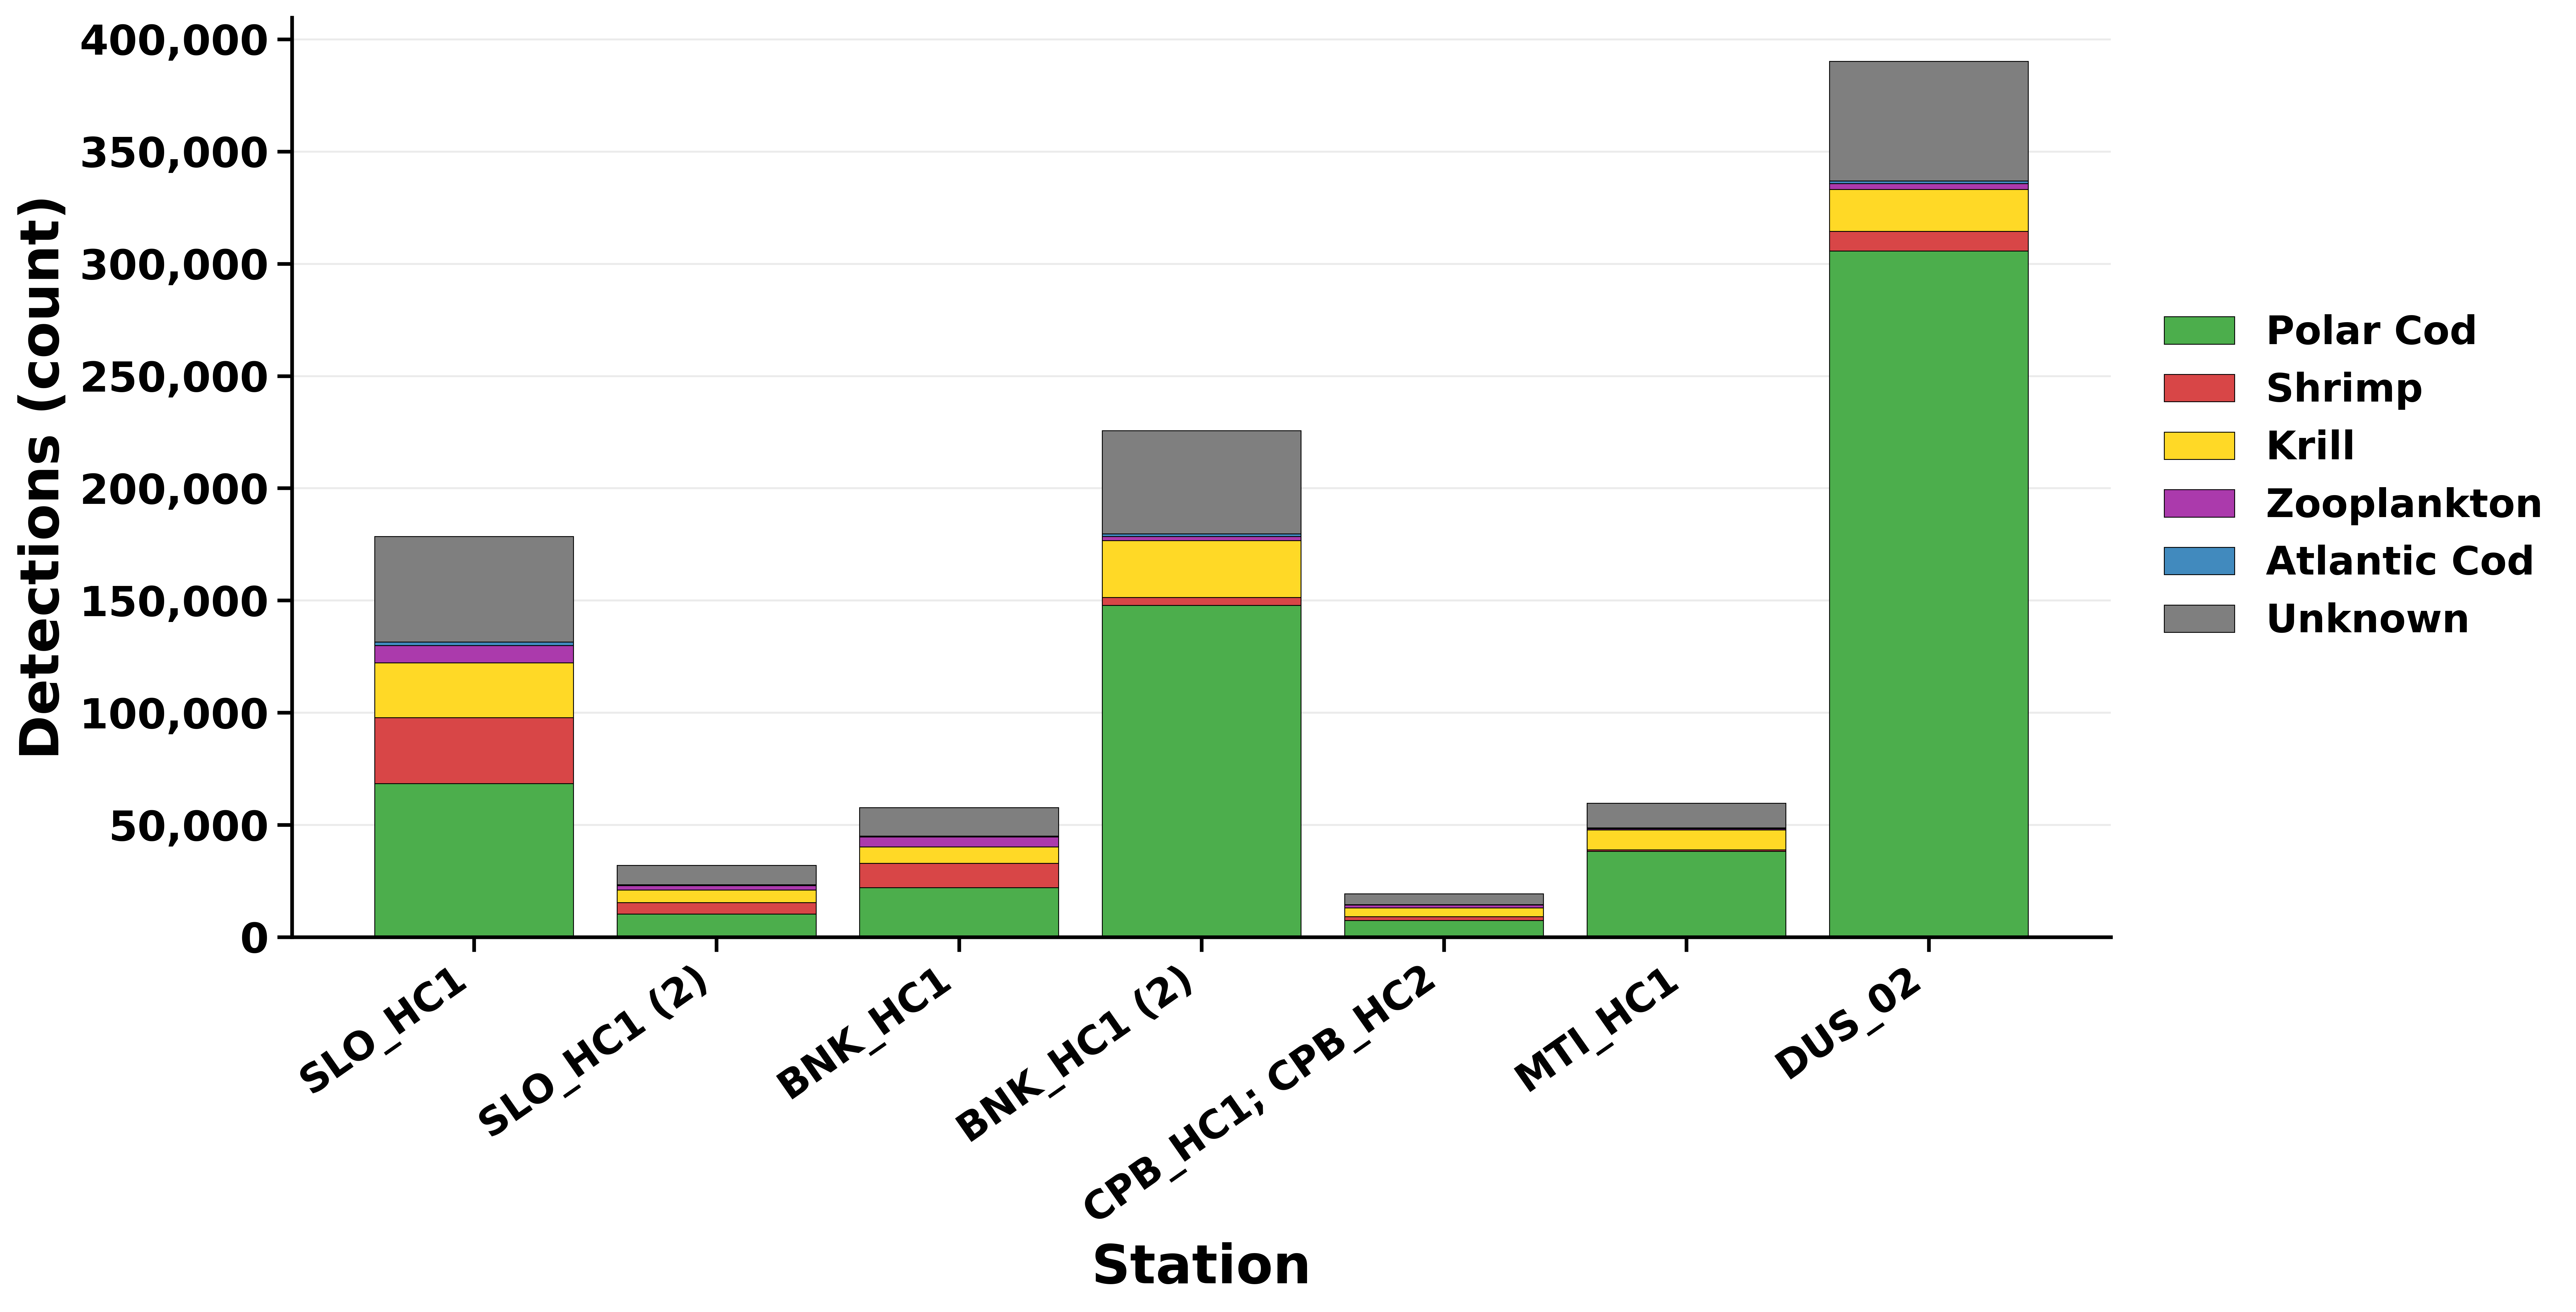

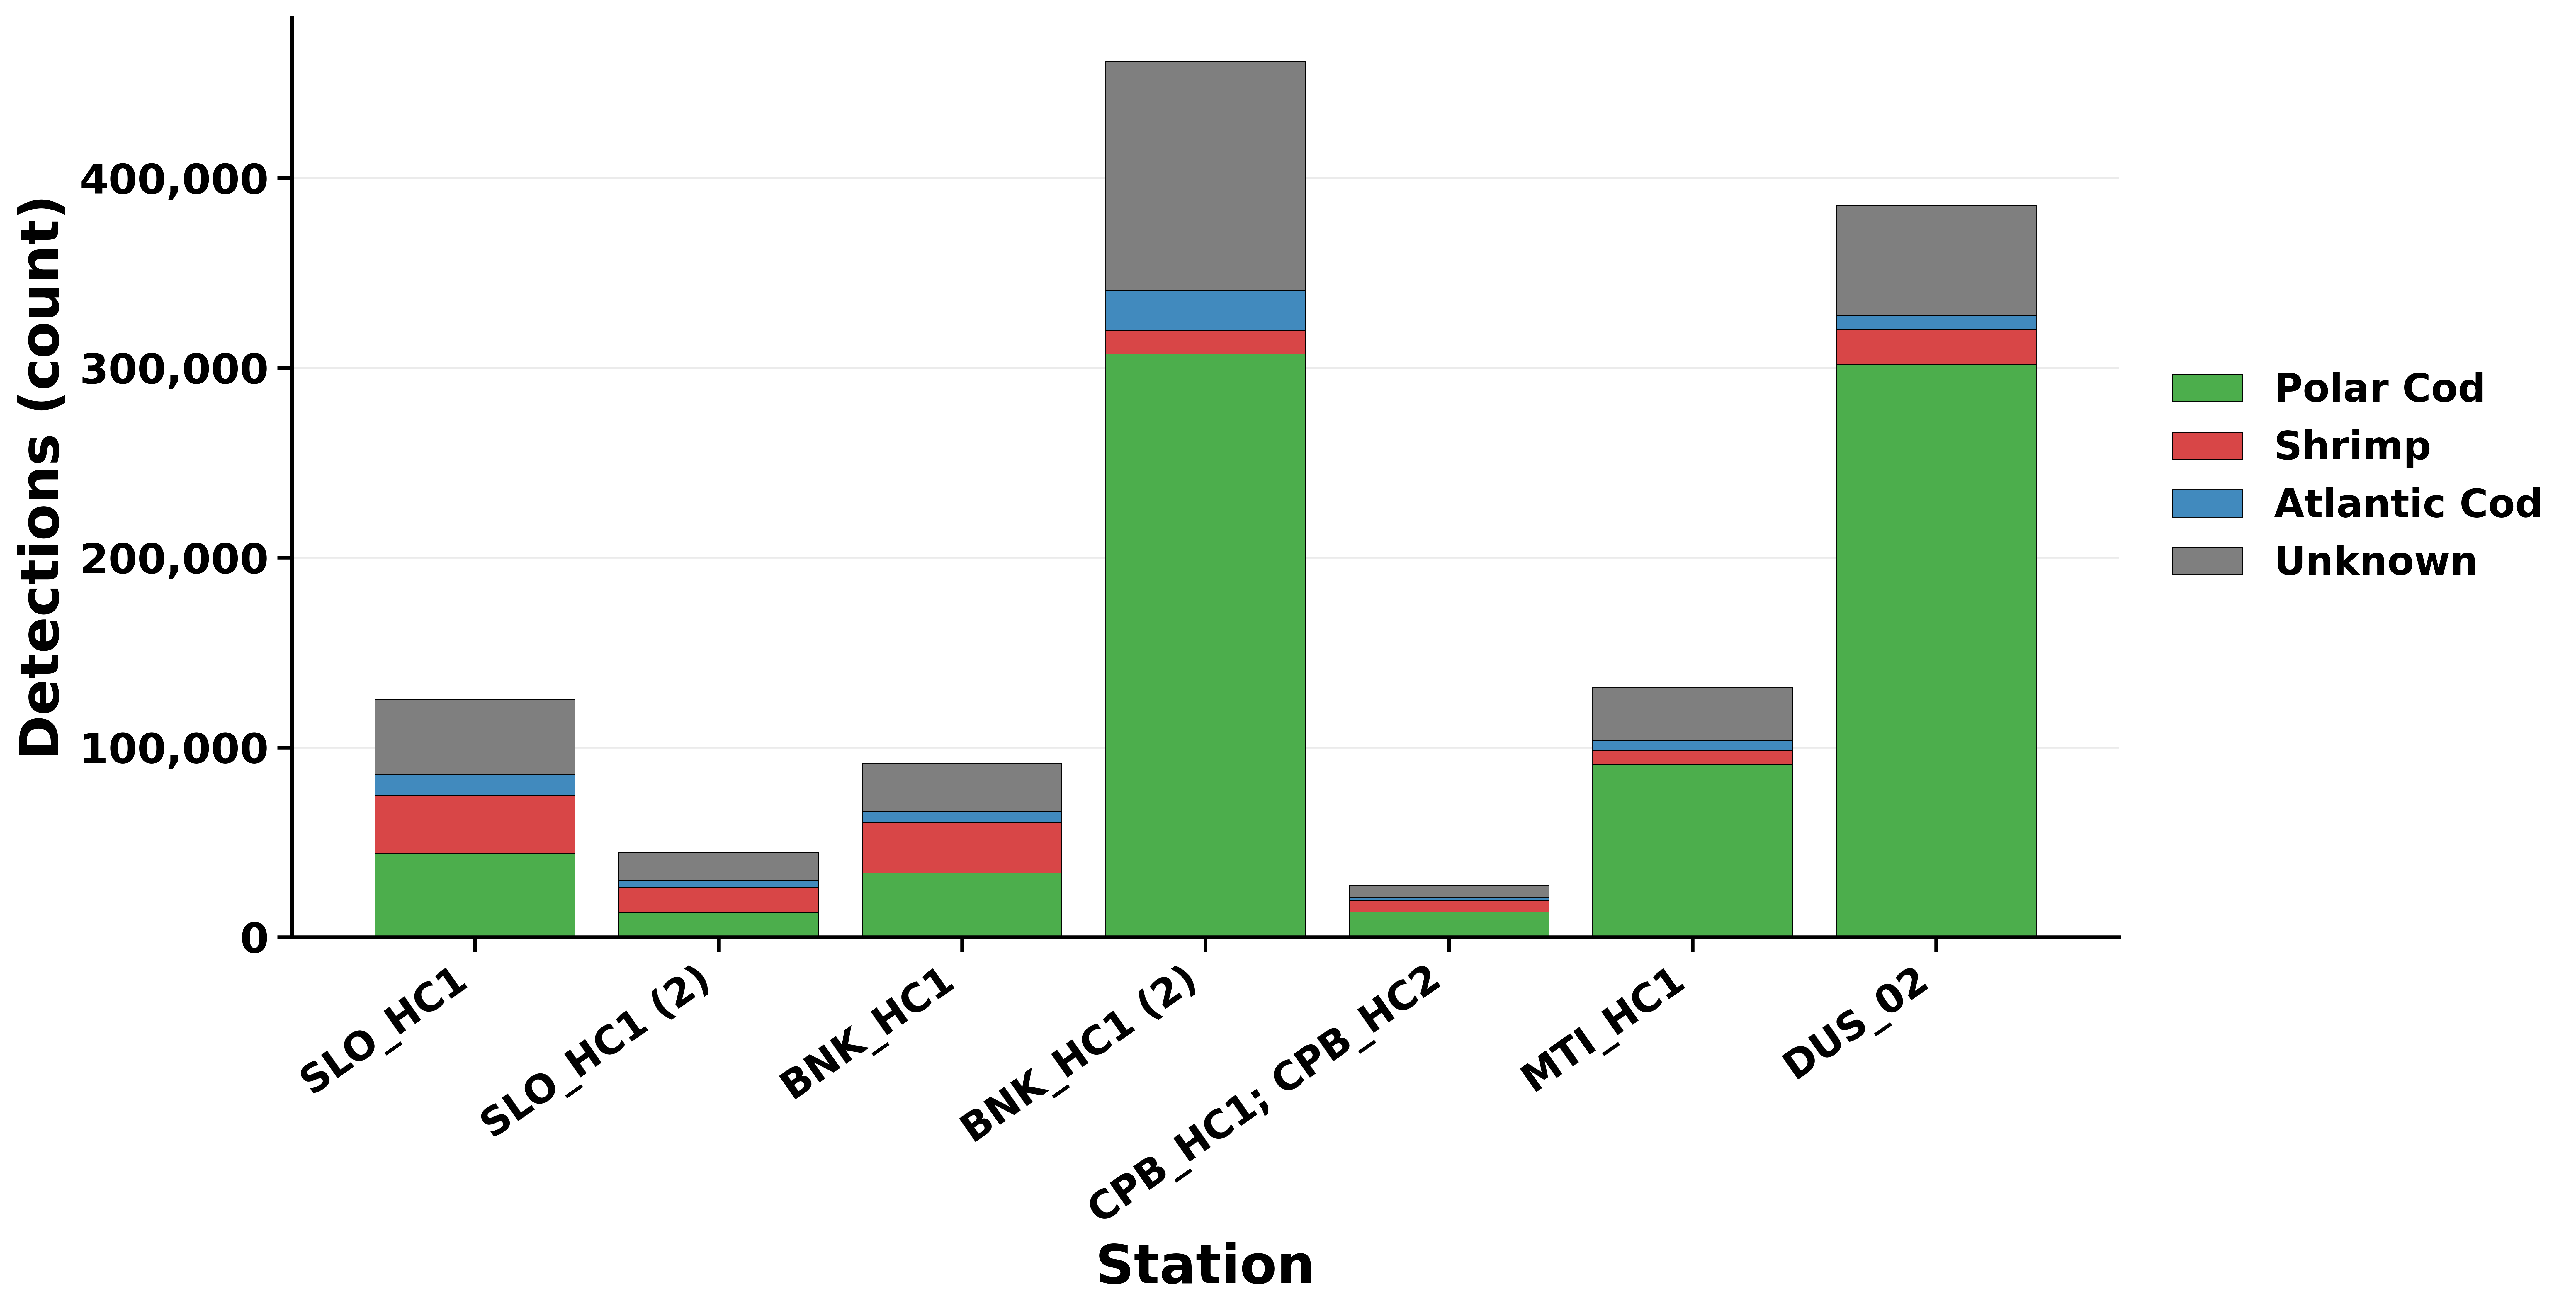

Saved:
 - filtered_station_stacked_totals_200khz_5_100m_final_publication.png
 - filtered_station_stacked_totals_120khz_5_100m_final_publication.png


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ----------------------------
# Colors
# ----------------------------
COLORS = {
    "Zooplankton":  "#ab3aac",
    "Polar Cod":    "#4cae4c",
    "Krill":        "#ffd926",
    "Atlantic Cod": "#418abe",
    "Shrimp":       "#d84647",
    "Unknown":      "#7f7f7f",
}

# ----------------------------
# 200 kHz counts: final filtered
# ----------------------------
data_200k_filtered = [
    ("SLO_HC1",           "Aug 9",      1641, 24345,  68368, 29496, 7659, 47008),
    ("SLO_HC1 (2)",       "Aug 9 (2)",   402,  5694,  10347,  5028, 1908,  8598),
    ("BNK_HC1",           "Aug 11",      372,  7198,  22030, 10921, 4500, 12737),
    ("BNK_HC1 (2)",       "Aug 11 (2)", 1190, 25285, 147786,  3580, 1877, 45930),
    ("CPB_HC1; CPB_HC2",  "Aug 15",      171,  3906,   7425,  1680, 1280,  4797),
    ("MTI_HC1",           "Aug 26",      326,  8975,  38287,   582,  509, 10997),
    ("DUS_02",            "Aug 29",     1131, 18645, 305731,  8793, 2570, 53286),
]

df200 = pd.DataFrame(
    data_200k_filtered,
    columns=[
        "Station", "Date",
        "Atlantic Cod", "Krill", "Polar Cod", "Shrimp", "Zooplankton", "Unknown"
    ]
)

# ----------------------------
# 120 kHz counts: final filtered
# ----------------------------
data_120k_filtered = [
    ("SLO_HC1",           "Aug 9",      10645,  43937, 30975,  39747),
    ("SLO_HC1 (2)",       "Aug 9 (2)",   3867,  12970, 13221,  14596),
    ("BNK_HC1",           "Aug 11",      5940,  33784, 26681,  25316),
    ("BNK_HC1 (2)",       "Aug 11 (2)", 20818, 307393, 12472, 120803),
    ("CPB_HC1; CPB_HC2",  "Aug 15",      1384,  13216,  6162,   6781),
    ("MTI_HC1",           "Aug 26",      5125,  90919,  7657,  28083),
    ("DUS_02",            "Aug 29",      7519, 301690, 18548,  57792),
]

df120 = pd.DataFrame(
    data_120k_filtered,
    columns=["Station", "Date", "Atlantic Cod", "Polar Cod", "Shrimp", "Unknown"]
)

# ----------------------------
# Plot helper: stacked bars
# ----------------------------
def stacked_bar_by_station_in_order(df, class_cols_bottom_to_top, outpath):
    stations = df["Station"].tolist()

    # Publication-readable font settings
    plt.rcParams.update({
        "font.size": 18,
        "font.weight": "bold",
        "axes.labelsize": 22,
        "axes.labelweight": "bold",
        "xtick.labelsize": 16,
        "ytick.labelsize": 17,
        "legend.fontsize": 16,
        "axes.linewidth": 1.5,
    })

    fig, ax = plt.subplots(figsize=(15, 7.8), dpi=600)

    bottoms = [0] * len(df)
    for c in class_cols_bottom_to_top:
        ax.bar(
            range(len(df)),
            df[c].values,
            bottom=bottoms,
            label=c,
            color=COLORS.get(c, None),
            width=0.82,
            edgecolor="black",
            linewidth=0.35,
        )
        bottoms = [b + v for b, v in zip(bottoms, df[c].values)]

    ax.set_ylabel("Detections (count)", fontsize=22, fontweight="bold")
    ax.set_xlabel("Station", fontsize=22, fontweight="bold")

    ax.set_xticks(range(len(df)))
    ax.set_xticklabels(
        stations,
        rotation=35,
        ha="right",
        fontsize=16,
        fontweight="bold"
    )

    # Make y-axis numbers bold
    for label in ax.get_yticklabels():
        label.set_fontsize(17)
        label.set_fontweight("bold")

    # Make x-axis numbers/labels bold again after draw setup
    for label in ax.get_xticklabels():
        label.set_fontsize(16)
        label.set_fontweight("bold")

    ax.tick_params(axis="both", which="major", width=1.5, length=6)

    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

    ax.grid(True, axis="y", alpha=0.25, linewidth=0.8)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)

    legend = ax.legend(
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        frameon=False,
        handlelength=1.8,
    )

    # Make legend text bold
    for text in legend.get_texts():
        text.set_fontweight("bold")
        text.set_fontsize(16)

    fig.tight_layout()
    fig.savefig(outpath, bbox_inches="tight", dpi=600)
    plt.show()

# ----------------------------
# Make final manuscript plots
# ----------------------------

# 200 kHz: Polar Cod on bottom
cols_200_bottom_to_top = [
    "Polar Cod", "Shrimp", "Krill", "Zooplankton", "Atlantic Cod", "Unknown"
]

stacked_bar_by_station_in_order(
    df200,
    class_cols_bottom_to_top=cols_200_bottom_to_top,
    outpath="filtered_station_stacked_totals_200khz_5_100m_final_publication.png",
)

# 120 kHz: Polar Cod on bottom
cols_120_bottom_to_top = [
    "Polar Cod", "Shrimp", "Atlantic Cod", "Unknown"
]

stacked_bar_by_station_in_order(
    df120,
    class_cols_bottom_to_top=cols_120_bottom_to_top,
    outpath="filtered_station_stacked_totals_120khz_5_100m_final_publication.png",
)

print("Saved:")
print(" - filtered_station_stacked_totals_200khz_5_100m_final_publication.png")
print(" - filtered_station_stacked_totals_120khz_5_100m_final_publication.png")